# (1) Example_MNIST_CNN_Train

Questo notebook contiene un esempio su come definire una Convolutional Neural Network (CNN) ed allenarla per eseguire Image Recognition sul dataset MNIST. La rete viene salvata alla fine del training.

## 1. Setup and Imports

Importiamo le librarie che ci serviranno

In [1]:

import numpy as np
import matplotlib.pyplot as plt
import torch
from torchvision import datasets, transforms
from tqdm import tqdm

## 2. Data Preparation

Scarica il dataset MNIST per allenare la rete

In [2]:
# Inference batch size
batch_size = 64

# Load the MNIST training set
mnist_data = datasets.MNIST("./", download=True, train=True,
                              transform=transforms.Compose([
                                transforms.ToTensor(),
                                transforms.Normalize((0.1307,), (0.3081,))  
                                ]),
                              target_transform=transforms.Compose([
                                lambda x:torch.tensor([x]), 
                                lambda x:torch.nn.functional.one_hot(x,10).float(),
                                lambda x:x.squeeze(),
                                ]))

# Load the MNIST test set
mnist_test = datasets.MNIST("./", download=True, train=False,
                              transform=transforms.Compose([
                                transforms.ToTensor(),
                                transforms.Normalize((0.1307,), (0.3081,))  
                                ]),
                              target_transform=transforms.Compose([
                                lambda x:torch.tensor([x]), 
                                lambda x:torch.nn.functional.one_hot(x,10).float(),
                                lambda x:x.squeeze(),
                                ]))

# Split dataset into training and validation and create data loaders
ds_train, ds_val = torch.utils.data.random_split(mnist_data, [0.8, 0.2])
mnist_loader_train = torch.utils.data.DataLoader(ds_train, batch_size=batch_size, shuffle=True)
mnist_loader_val = torch.utils.data.DataLoader(ds_val, batch_size=batch_size, shuffle=False)

# Create test set loader
mnist_loader_test = torch.utils.data.DataLoader(mnist_test, batch_size=batch_size, shuffle=False)
N_test = len(mnist_loader_test.dataset)

## 3. Define the CNN Model

Definisci la tua rete neurale

In [3]:
# Define the CNN topology
def mnist_cnn():
    return torch.nn.Sequential(
        torch.nn.Conv2d(1, 8, 3, padding='valid', stride=2),
        torch.nn.ReLU(),
        torch.nn.Conv2d(8, 16, 3, padding='valid', stride=2),
        torch.nn.ReLU(),
        torch.nn.Flatten(),
        torch.nn.Linear(576, 16),
        torch.nn.ReLU(),
        torch.nn.Linear(16, 10)
        )

## 4. Training and Testing Functions

Definisci una funzione Wrapper che esponga un'interfaccia per lanciare training e testing sul modello.
Questa procedura non é "standard" Pythorch ma facilita l'utilizzo successivo del framework Cross-Sim per modellare l'implementazione via In-Memory Computing.

Per il training viene utilizzato l'ottimizzatore Adam con learning rate a $10^{-3}$.

In [4]:
# Wrapper for training the CNN
class SequentialWrapper():
    def __init__(self, net, loss, learning_rate=1e-3):
        self.net = net
        self.loss = loss
        self.learning_rate = learning_rate
        self.optimizer = torch.optim.Adam(self.net.parameters(), lr=self.learning_rate)

    def forward(self, x):
        return self.net(x)
    
    def training_step(self, batch):
        self.optimizer.zero_grad()
        pred = self.forward(batch[0])
        loss = self.loss(pred, batch[1])
        loss.backward()
        self.optimizer.step()
        return loss

    def validation_step(self, batch):
        pred = self.forward(batch[0])
        loss = self.loss(pred, batch[1])
        return loss
    
    def train_epoch(self, train_loader, val_loader):
        loss_train, loss_val = 0, 0
        for minibatch in iter(train_loader):
            loss_train += self.training_step(minibatch).detach()
        for minibatch in iter(val_loader):
            loss_val += self.validation_step(minibatch).detach()
        return loss_train/len(train_loader), loss_val/len(val_loader)
    
    def train(self, train_loader, val_loader, epochs):
        loss_train, loss_val = np.zeros(epochs), np.zeros(epochs)
        for e in tqdm(range(0, epochs)):
            lt, lv = self.train_epoch(train_loader, val_loader)
            loss_train[e] = lt
            loss_val[e] = lv
        return loss_train, loss_val

# Create the wrapped PyTorch of the CNN model
mnist_cnn_pt = SequentialWrapper(mnist_cnn(), torch.nn.CrossEntropyLoss())

## 5. PyTorch Training

Allena (_training_) la rete per il numero di _epoche_ indicato.


In [5]:
# Number of training epochs
N_epochs = 20

# Train the standard PyTorch CNN
loss_train_pt, loss_val_pt = mnist_cnn_pt.train(mnist_loader_train, mnist_loader_val, N_epochs)


  0%|          | 0/20 [00:00<?, ?it/s]

100%|██████████| 20/20 [33:09<00:00, 99.47s/it] 


Rappresenta poi la funzione costo (_loss_) per il subset di _training_ e di _testing_ per valutare eventuale overfitting.

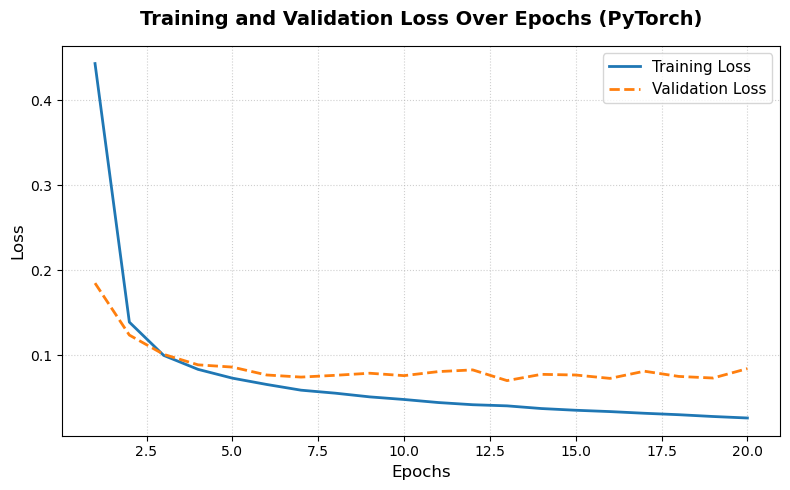

In [6]:
x_axis_epochs = np.arange(1, len(loss_train_pt) + 1)

# Initialize the plot layout
plt.figure(figsize=(8, 5))

# Plot both curves
plt.plot(x_axis_epochs, loss_train_pt, label='Training Loss', color='#1f77b4', linewidth=2)
plt.plot(x_axis_epochs, loss_val_pt, label='Validation Loss', color='#ff7f0e', linewidth=2, linestyle='--')

# Add descriptive elements
plt.title('Training and Validation Loss Over Epochs (PyTorch)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11)

# Display the chart
plt.tight_layout()
# plt.show()
plt.savefig('train_val_loss_pytorch.png', bbox_inches='tight', dpi=200)

## 6. PyTorch Inference

Una volta soddisfatto dal training, valuta l'accuratezza della rete su un subset completamente nuovo (_testing_).

In [7]:

# Perform inference on the test set, with no analog errors
y_pred, y, k = np.zeros(N_test), np.zeros(N_test), 0
for inputs, labels in mnist_loader_test:
    with torch.no_grad():
        output = mnist_cnn_pt.net(inputs)
        y_pred_k = output.data.detach().numpy()
        y_pred = np.append(y_pred,y_pred_k.argmax(axis=-1))
        y = np.append(y,labels.detach().numpy().argmax(axis=1))

# Evaluate accuracy
accuracy_digitalTrain_digitalTest = np.sum(y == y_pred)/len(y)
print('===========')
print('No analog errors during training, no analog errors during test')
print('Test accuracy: {:.2f}%\n'.format(accuracy_digitalTrain_digitalTest*100))

No analog errors during training, no analog errors during test
Test accuracy: 98.88%



In [8]:
# Save the model
torch.save(mnist_cnn_pt.net.state_dict(), "trained_mnist_cnn.pt")